In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px

from non_parametric_pro import ula

from non_parametric_pro.density import ProParameters, pro_logdensity_fn, pro_score_fn
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import prediction_basis, nlpd_gp, nlpd_pro, crps_gp, crps_pro
from non_parametric_pro.data.uci import load_uci_regression_dataset
from non_parametric_pro.adaptation.parameter_adaptation import parameter_adaptation
from non_parametric_pro.inducing import PointInducingBasis, compute_inducing_basis, kmeans_inducing_points
from non_parametric_pro.gp import _full_gp_basis
from non_parametric_pro.wrap import wrap

import blackjax
from blackjax.util import run_inference_algorithm

from sklearn.preprocessing import StandardScaler

jax.config.update("jax_enable_x64", True)
mala = wrap(blackjax.mala)

In [2]:
key = jr.PRNGKey(0)

example = load_uci_regression_dataset("concrete", split=1)

scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train = scaler_x.fit_transform(example.x_train)
y_train = scaler_y.fit_transform(example.y_train)

x_test = scaler_x.transform(example.x_test)
y_test = scaler_y.transform(example.y_test)

In [23]:
M = 300

D = x_train.shape[1]
N = x_train.shape[0]

data = gpx.Dataset(X=x_train, y=y_train)
kernel = gpx.kernels.Matern32(lengthscale=jnp.ones((D,)))
prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood
optim = ox.adam(learning_rate=0.01)

z_init = kmeans_inducing_points(key, x_train, M).z 

variational_family = gpx.variational_families.CollapsedVariationalGaussian(
    posterior=posterior,
    inducing_inputs=z_init,
)

opt_variational_family, _ = gpx.fit(
    model=variational_family,
    objective=lambda p, d: -gpx.objectives.collapsed_elbo(p, d),
    train_data=data,
    optim=optim,
    num_iters=1000,
    verbose=False,
)

gp_posterior = opt_variational_family.posterior

gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

gp_sigma = gp_posterior.likelihood.obs_stddev
gp_kernel = gp_posterior.prior.kernel

z_opt = px.unwrap(opt_variational_family.inducing_inputs)

In [5]:
D = x_train.shape[1]

data = gpx.Dataset(X=x_train, y=y_train)
kernel = gpx.kernels.RBF(lengthscale=jnp.ones((D,)))
prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood

optim = ox.adam(learning_rate=0.01)

gp_posterior, _ = gpx.fit(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=data,
    optim=optim,
    num_iters=500,
    verbose=False,
)

gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

gp_sigma = gp_posterior.likelihood.obs_stddev
gp_kernel = gp_posterior.prior.kernel

print("GP NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))

GP NLPD: -0.011949661659540848


In [ ]:
inducing = False

if inducing:
    key, subkey = jr.split(key)
    inducing_idx = jr.choice(subkey, x_train.shape[0], shape=(M,), replace=False)
    inducing_basis = PointInducingBasis(x_train[inducing_idx])
    basis, residual_std = compute_inducing_basis(inducing_basis, gp_kernel, x_train)
else:
    M = x_train.shape[0]
    basis, residual_std = _full_gp_basis(gp_posterior, x_train, jitter=1e-4), None

sigma = gpx.parameters.SigmoidBounded(px.unwrap(gp_sigma), low=0.15, high=100.0)

pro_params = ProParameters(
    y=y_train,
    basis=basis,
    step_size=1e-4,
    sigma=sigma,
    alpha=1.0,
    residual_std=residual_std
)

J = 60

initial_position = jr.normal(key, (M, J))

Running parameter adaptation


<div><progress max="3000" value="3000"></progress> 100.00% [3000/3000 00:00&lt;?]</div>

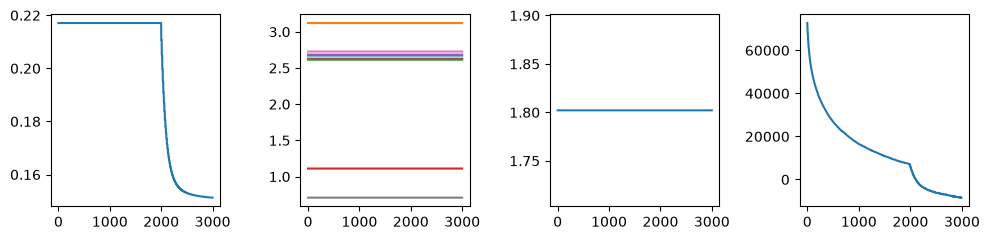

In [8]:
adapt = True

if adapt:

    adaptation = parameter_adaptation(
        ula,
        pro_logdensity_fn,
        pro_params,
        x_train=x_train,
        initial_kernel=gp_kernel,
        warmup_steps=2000,
        sigma_adapt_every=10,
        kernel_adapt_every=-1,
        objective_fn=pro_score_fn,
        inducing_basis=inducing_basis if inducing else None,
        sigma_optimizer=ox.adam(1e-1),
        kernel_optimizer=ox.adam(1e-2),
        progress_bar=True
    ) 

    adaptation_results, adaptation_info = adaptation.run(key, initial_position, num_steps=3000)
    adaptation_kernel = jax.tree.map(lambda x: x[-1], adaptation_info.kernel)
    adaptation_params = adaptation_results.parameters
    adaptation_position = adaptation_results.state.position

    fig, ax = plt.subplots(1, 4, figsize=(10, 2.5))

    ax[0].plot(px.unwrap(adaptation_info.sigma))
    ax[1].plot(px.unwrap(adaptation_info.kernel.lengthscale))
    ax[2].plot(px.unwrap(adaptation_info.kernel.variance))
    ax[3].plot(-adaptation_info.sampler_info.score[10:])
    plt.tight_layout()
    plt.show()

In [ ]:
# adaptation_params = adaptation_params._replace(step_size=0.0001)
# pro_params = pro_params._replace(step_size=0.0001)
# num_steps = 1000


# algorithm = parametric_ula(pro_logdensity_fn, adaptation_params if adapt else pro_params)

# # algorithm = blackjax.mala(
# #     lambda z: pro_logdensity_fn(z, adaptation_params if adapt else pro_params),
# #     adaptation_params.step_size if adapt else pro_params.step_size,
# # )

# out, info = run_inference_algorithm(
#     rng_key=key,
#     inference_algorithm=algorithm,
#     num_steps=num_steps,
#     initial_position=adaptation_position if adapt else initial_position,
#     progress_bar=True
# )

# plt.plot(-info[1].score)
# plt.show()

<div><progress max="5000" value="5000"></progress> 100.00% [5000/5000 00:00&lt;?]</div>

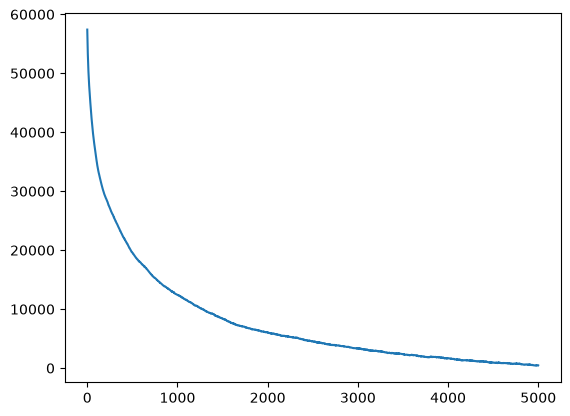

In [ ]:
num_steps = 5000

sigma = gpx.parameters.SigmoidBounded(0.15, low=0.1, high=100.0)

pro_params = ProParameters(
    y=y_train,
    basis=basis,
    step_size=0.0001,
    sigma=sigma,
    alpha=1.0,
    residual_std=residual_std,
    jitter=1e-4
)

J = 40

initial_position = jr.normal(key, (M, J))

algorithm = parametric_ula(pro_logdensity_fn, pro_params)

# algorithm = blackjax.mala(
#     lambda z: pro_logdensity_fn(z, adaptation_params if adapt else pro_params),
#     adaptation_params.step_size if adapt else pro_params.step_size,
# )

out, info = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=algorithm,
    num_steps=num_steps,
    initial_position=initial_position,
    progress_bar=True
)

plt.plot(-info[1].score)
plt.show()

In [20]:
burn = int(num_steps // 1.3)

particles = info[0].position[burn:][::10]

test_basis, test_cov = prediction_basis(gp_kernel, x_train, x_test, pro_params, inducing_basis=inducing_basis if inducing else None)

print("PRO NLPD:", nlpd_pro(y_test, test_basis, test_cov, particles, sigma=pro_params.sigma))
print("GP NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))


PRO NLPD: 0.11883447399814924
GP NLPD: -0.011949661659540848


In [225]:
print("PRO CRPS:", crps_pro(example.y_test, test_basis, test_cov, out.position, sigma=pro_params.sigma))
print("GP CRPS:", crps_gp(example.y_test, gp_predictive_mean, gp_predictive_std))

PRO CRPS: 13.32653983301859
GP CRPS: 13.369825183279131
